# Fashion-MNIST

Loads Fashion-MNIST IDX image files, validates them, visualizes samples, and performs GPU-ready tensor testing.

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.3148 - loss: 1.8439 - val_accuracy: 0.4255 - val_loss: 1.5823
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4571 - loss: 1.4978 - val_accuracy: 0.5215 - val_loss: 1.3474
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5249 - loss: 1.3100 - val_accuracy: 0.5610 - val_loss: 1.2294
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5888 - loss: 1.1598 - val_accuracy: 0.5475 - val_loss: 1.2791
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6409 - loss: 1.0081 - val_accuracy: 0.5765 - val_loss: 1.2008

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━

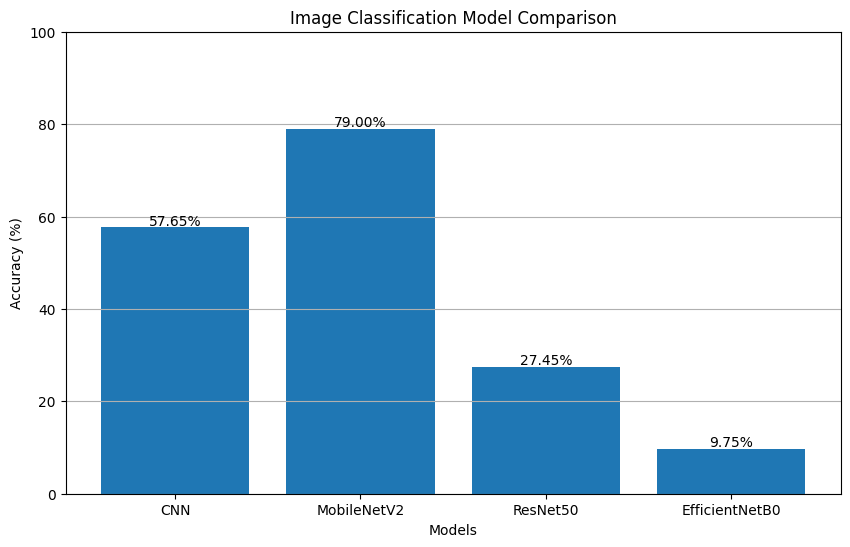


Best Model: MobileNetV2
Best Accuracy: 79.0 %


In [1]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MOBILE NET V2
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =====================================================
# RESNET50
# =====================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =====================================================
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")

In [ ]:

import torch
import numpy as np
import struct
import matplotlib.pyplot as plt
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


## Set Dataset Path

In [ ]:

DATASET_PATH = "train-images-idx3-ubyte"

assert Path(DATASET_PATH).exists()

print(DATASET_PATH)


## Load IDX Images

In [ ]:

def load_idx_images(path):
    with open(path, "rb") as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))

        print("Magic:", magic)
        print("Images:", n_images)

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        ).reshape(n_images, rows, cols)

    return data

images = load_idx_images(DATASET_PATH)

print(images.shape)


## Dataset Statistics

In [ ]:

print("Min:", images.min())
print("Max:", images.max())
print("Mean:", images.mean())
print("Std:", images.std())


## Visualize Samples

In [ ]:

idx = np.random.choice(
    len(images),
    25
)

fig, axes = plt.subplots(
    5,5,
    figsize=(8,8)
)

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(images[i], cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Convert to GPU Tensors

In [ ]:

tensor_images = torch.tensor(
    images,
    dtype=torch.float32
) / 255.0

tensor_images = tensor_images.unsqueeze(1)

tensor_images = tensor_images.to(device)

print(tensor_images.shape)
print(tensor_images.device)


## Batch Testing

In [ ]:

batch = tensor_images[:1024]

print(batch.shape)

memory_mb = (
    batch.element_size()
    * batch.nelement()
) / (1024**2)

print("Memory MB:", round(memory_mb,2))


## Notes

Upload label files later if you want training support.